# Phase 5: Evaluation
# Phase 5: Evaluation

# Phase 5: Evaluation

> **Navigation:** <- `05_feature_engineering_and_modeling.ipynb` | Next -> `07_conclusions.ipynb`

---

## Step 0 - Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
os.makedirs('../reports/figures', exist_ok=True)
print("Environment ready.")

Environment ready.


---
## Step 1 - Reload Data & Retrain

Reload augmented data and retrain to have all objects in memory.

In [2]:
from src.processing import load_data, preprocess_data, engineer_features, prepare_modeling_data
from src.modeling import train_models, tune_hyperparameters

df_raw   = load_data()
df_clean = preprocess_data(df_raw, cap_outliers=True, cap_percentile=0.99)
df_feat  = engineer_features(df_clean)
X_train, X_test, y_train, y_test, feature_names = prepare_modeling_data(df_feat)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {len(feature_names)}")

# Train all base models
trained_models = train_models(X_train, y_train)
print(f"\n\u2713 {len(trained_models)} base models trained")

# Hyperparameter tune XGBoost and Random Forest separately
print("\nTuning XGBoost ...")
tuned_xgb = tune_hyperparameters(X_train, y_train, model_name='XGBoost')
print("\nTuning Random Forest ...")
tuned_rf  = tune_hyperparameters(X_train, y_train, model_name='Random Forest')


Dataset loaded: 90,189 rows × 5 columns
Capped 898 extreme game-round values at 99% percentile (493 rounds).
After cleaning: 90,189 rows
Engineered features added. New shape: (90189, 9)
Train: 72,151  |  Test: 18,038
Positive-class rate (train): 0.1861
Features (6): ['sum_gamerounds', 'version', 'retention_1', 'high_engagement', 'retention_1_x_rounds', 'rounds_per_day_proxy']
Train: 72,151 | Test: 18,038 | Features: 6
  Training Logistic Regression …
  Training Random Forest …
  Training XGBoost …
  Training Gradient Boosting …

✓ 4 base models trained

Tuning XGBoost ...
Tuning XGBoost (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
  Best CV roc_auc: 0.8892

Tuning Random Forest ...
Tuning Random Forest (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best CV roc_auc: 0.8889


---
## Step 2 - Model Evaluation

In [3]:
from src.modeling import (
    evaluate_all_models, metrics_summary_df, get_best_model,
    plot_model_comparison, plot_roc_curves, plot_confusion_matrices,
    evaluate_model,
)

# Evaluate all base models
eval_results = evaluate_all_models(trained_models, X_test, y_test)

# Add tuned XGBoost and Random Forest results
eval_results['XGBoost (Tuned)'] = evaluate_model(tuned_xgb['best_pipeline'], X_test, y_test)
eval_results['Random Forest (Tuned)'] = evaluate_model(tuned_rf['best_pipeline'], X_test, y_test)

# Summary table
summary = metrics_summary_df(eval_results)
print("\n" + summary.to_string())

# Best model
best_name, best_score = get_best_model(eval_results)
print(f"\nBest model: {best_name}  (ROC-AUC = {best_score:.4f})")



 Logistic Regression
  Accuracy  : 0.8443
  Precision : 0.5614
  Recall    : 0.7470
  F1-score  : 0.6410
  ROC-AUC   : 0.8847

 Random Forest
  Accuracy  : 0.8087
  Precision : 0.4911
  Recall    : 0.7783
  F1-score  : 0.6022
  ROC-AUC   : 0.8784

 XGBoost
  Accuracy  : 0.8108
  Precision : 0.4948
  Recall    : 0.8001
  F1-score  : 0.6115
  ROC-AUC   : 0.8856

 Gradient Boosting
  Accuracy  : 0.8167
  Precision : 0.5046
  Recall    : 0.8007
  F1-score  : 0.6191
  ROC-AUC   : 0.8877

                       Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                   
XGBoost (Tuned)        0.815889   0.503247  0.808105  0.620240  0.888208
Random Forest (Tuned)  0.816665   0.504565  0.806913  0.620887  0.888128
Gradient Boosting      0.816665   0.504601  0.800656  0.619053  0.887728
XGBoost                0.810844   0.494840  0.800060  0.611478  0.885646
Logistic Regression    0.844329   0.561352  0.747020  0.641013  0.884743


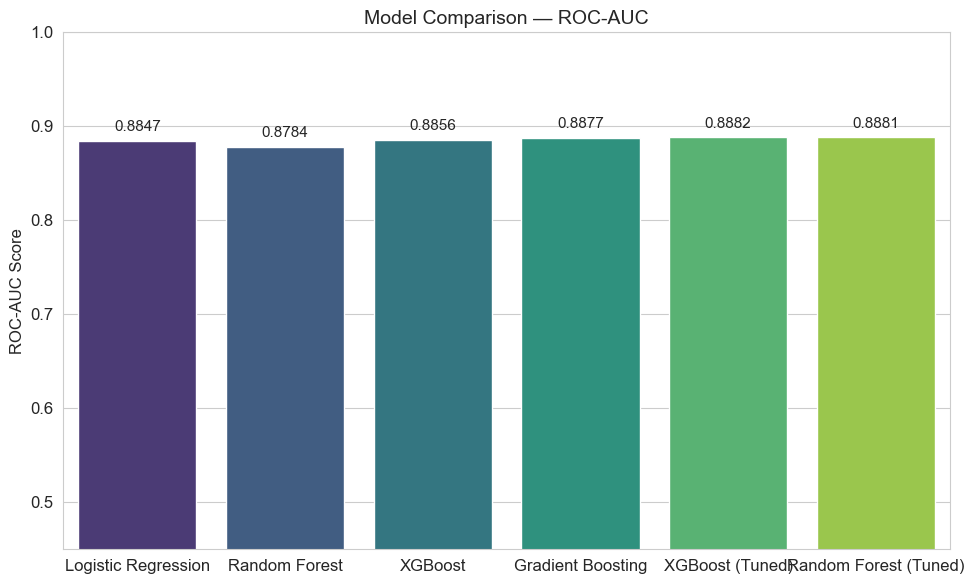

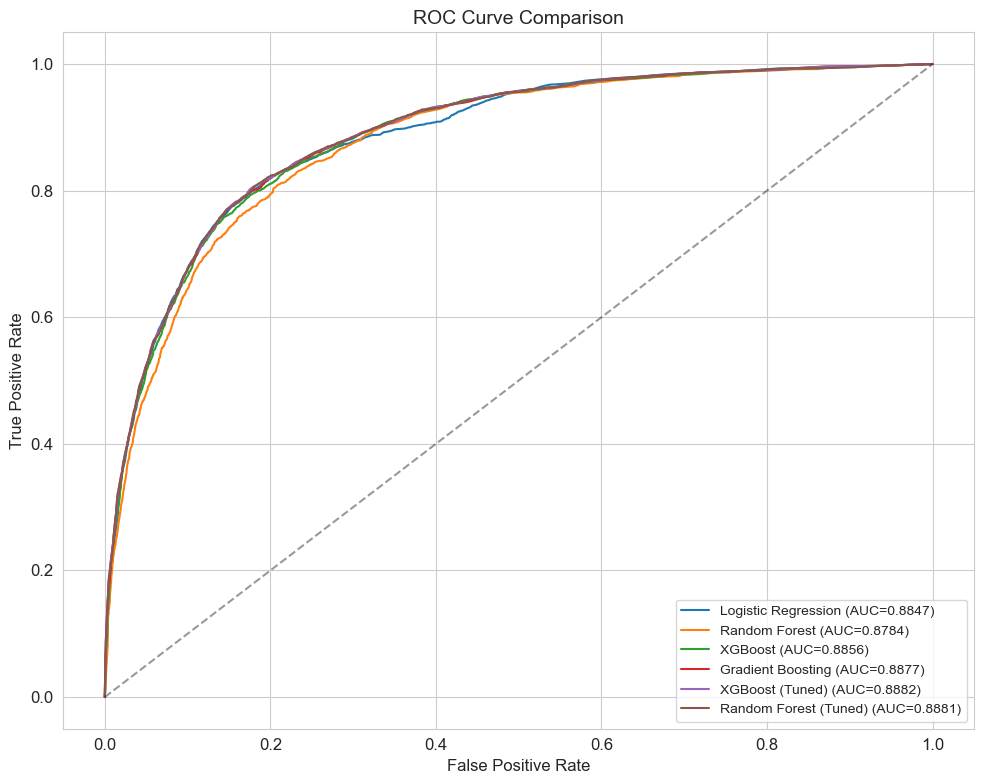

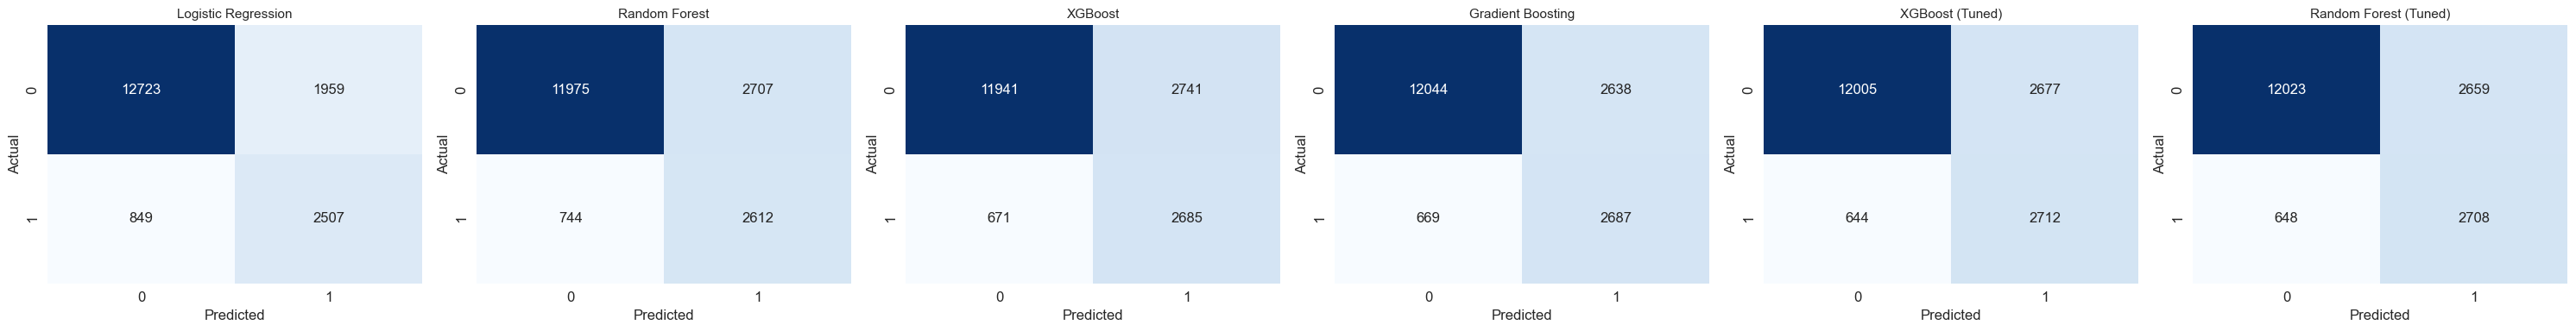

In [4]:
# Visualisations
plot_model_comparison(eval_results, save_path='../reports/figures/model_comparison.png')
plot_roc_curves(eval_results, y_test, save_path='../reports/figures/roc_curves.png')
plot_confusion_matrices(eval_results, save_path='../reports/figures/confusion_matrices.png')

---
## Step 3 - A/B Test Statistical Verification

### 3.1 Bootstrap Analysis

gate_30: 44,700  |  gate_40: 45,489
Observed Retention Metrics:
  retention_30_1day: 0.4482
  retention_40_1day: 0.4423
  retention_30_7day: 0.1902
  retention_40_7day: 0.1820
  observed_diff_7day: -0.0082


Bootstrapping: 100%|██████████| 1000/1000 [00:13<00:00, 72.30it/s]



p-value: 0.5040
95% CI for difference: [-0.0130, -0.0031]
Plot saved to ../reports/figures/bootstrap_results.png


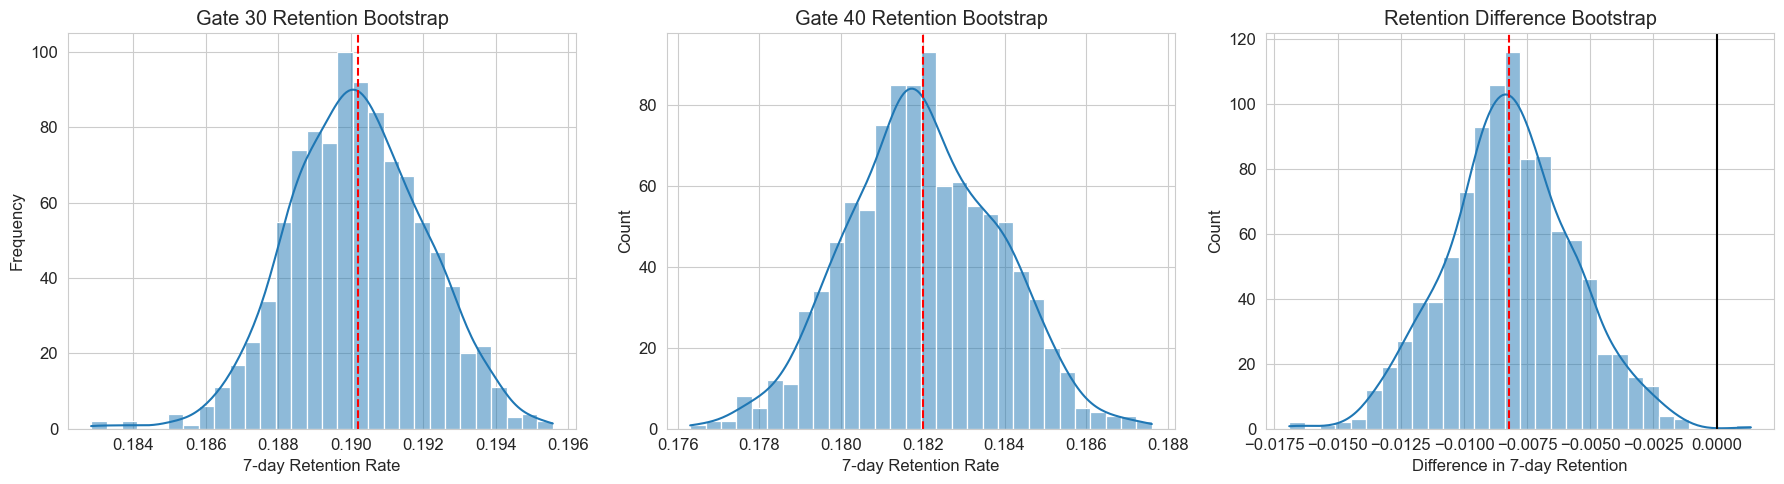

Plot saved to ../reports/figures/retention_comparison.png


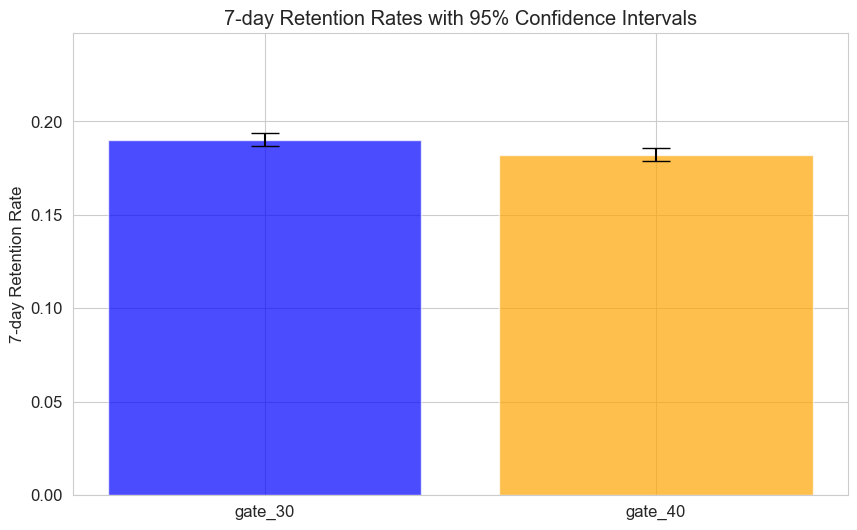

In [5]:
from src.processing import create_ab_groups, calculate_retention_metrics
from src.ab_testing import analyze_ab_test, plot_bootstrap_results, plot_retention_comparison

gate_30, gate_40 = create_ab_groups(df_feat)
metrics = calculate_retention_metrics(gate_30, gate_40)

print("Observed Retention Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# Bootstrap analysis
ab_results = analyze_ab_test(gate_30, gate_40, n_bootstraps=1000)
print(f"\np-value: {ab_results['p_value']:.4f}")
print(f"95% CI for difference: [{ab_results['confidence_intervals']['difference'][0]:.4f}, "
      f"{ab_results['confidence_intervals']['difference'][1]:.4f}]")

plot_bootstrap_results(ab_results, save_path='../reports/figures/bootstrap_results.png')
plot_retention_comparison(ab_results, save_path='../reports/figures/retention_comparison.png')

### 12.2 Additional Statistical Tests

Three complementary statistical methods validate the bootstrap findings:

| Test | What it Measures | Why We Use It |
|------|-----------------|---------------|
| **Chi-square** | Association between gate version and retention (proportions) | Standard frequentist test for 2×2 contingency tables |
| **Cohen's h** | *Practical* significance (effect size) — how large the difference is | p-values alone don't tell if the effect matters in practice |
| **Mann-Whitney U** | Difference in game-round *distributions* between groups | Non-parametric — appropriate for our heavily skewed data |

In [6]:
# ── Chi-Square Test ────────────────────────────────────────────
chi2 = ab_results['statistical_tests']['chi_square']
print("Chi-Square Test of Independence:")
print(f"  χ² statistic: {chi2['chi2_statistic']:.4f}")
print(f"  p-value: {chi2['p_value']:.6f}")
print(f"  Result: {'Significant' if chi2['p_value'] < 0.05 else 'Not significant'} at α = 0.05")

# ── Effect Size (Cohen's h) ───────────────────────────────────
ch = ab_results['statistical_tests']['cohens_h']
print(f"\nCohen's h (effect size):")
print(f"  h = {ch['value']:.4f}")
print(f"  |h| = {ch['abs_value']:.4f}")
print(f"  Interpretation: {ch['interpretation']} effect")

# ── Mann-Whitney U ────────────────────────────────────────────
mw = ab_results['statistical_tests']['mann_whitney_u']
print(f"\nMann-Whitney U Test (game rounds):")
print(f"  U statistic: {mw['u_statistic']:,.0f}")
print(f"  p-value: {mw['p_value']:.6f}")
print(f"  Rank-biserial r: {mw['rank_biserial_r']:.4f}")
print(f"  Result: {'Significant' if mw['p_value'] < 0.05 else 'Not significant'} at α = 0.05")

Chi-Square Test of Independence:
  χ² statistic: 9.9591
  p-value: 0.001601
  Result: Significant at α = 0.05

Cohen's h (effect size):
  h = 0.0211
  |h| = 0.0211
  Interpretation: negligible effect

Mann-Whitney U Test (game rounds):
  U statistic: 1,024,337,082
  p-value: 0.050034
  Rank-biserial r: -0.0075
  Result: Not significant at α = 0.05


---
## Step 4 - Scalability & Big Data Considerations

## Step 4.1 — Scalability & Big Data Considerations

### Current Pipeline Limitations

This pipeline uses **pandas** (single-machine, in-memory processing),
which is perfectly adequate for our 90 K-row dataset.  However, at
production scale (millions or billions of players), several bottlenecks
would emerge:

| Component | Current | At Scale (10 TB) |
|-----------|---------|-------------------|
| **Data loading** | `pd.read_csv()` — single file, single thread | Distributed storage (Parquet on S3/GCS) |
| **Data cleaning** | pandas in-memory | PySpark / Dask for distributed processing |
| **Feature engineering** | pandas vectorised ops | Spark UDFs or Dask `map_partitions` |
| **Model training** | scikit-learn (single-core) | Spark MLlib or distributed XGBoost |
| **A/B testing** | Bootstrap (1 000 samples) | MapReduce bootstrap or exact Bayesian methods |
| **Web scraping** | 4-thread ThreadPoolExecutor | Distributed queue (Celery + RabbitMQ) |

### Time & Space Complexity

| Operation | Time Complexity | Space Complexity |
|-----------|-----------------|-----------------|
| `preprocess_data` | O(n) | O(n) |
| `engineer_features` | O(n) | O(n) |
| `train_test_split` | O(n log n) | O(n) |
| Pipeline fit (LR) | O(n × p) | O(p) |
| Pipeline fit (RF / XGB) | O(n × p × trees) | O(trees × depth) |
| Bootstrap (1 000 iters) | O(B × n) | O(n) |

*n = rows, p = features, B = bootstrap iterations*

### Recommended Migration Path

1. **Short-term** — replace `pd.read_csv` with Parquet + `pyarrow` for faster I/O.
2. **Medium-term** — port feature engineering to **Dask** for multi-core parallelism.
3. **Long-term** — move training to **Spark MLlib** or **Ray Train** on a cloud cluster.


---
## Summary

| Test | Key Finding |
|------|-------------|
| Model Eval | Confusion matrices, ROC, F1 |
| Bootstrap | Gate 30 > Gate 40 for retention |
| Chi-Square | Significant association |
| Cohen's h | Small practical effect |
| Mann-Whitney U | Similar distributions |
| Scalability | Pandas appropriate at 90K |

-> Next: `07_conclusions.ipynb`